# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**DenseNet-169 Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a DenseNet-169 model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [ ]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.densenet_utils import build_densenet169_model
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

# gpus = tf.config.experimental.list_physical_devices('GPU')
# if gpus:
#     for gpu in gpus:
#         tf.config.experimental.set_memory_growth(gpu, True)

2025-03-25 14:41:02.940970: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-25 14:41:02.954209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742913662.969715   33171 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742913662.974808   33171 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-25 14:41:02.991613: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Core Variables

In [2]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'dense_169_test' # Name of the model to be saved
BEST_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_best_model.keras'
FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_pneumonia_model.keras'

# Training parameters
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.01
DROPOUT_RATE = 0.5
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'

# Data Loading & Preprocessing

In [3]:
train_images, train_labels, test_images, test_labels, val_images, val_labels = load_and_preprocess_data(DATA_PATH)


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# DenseNet-169 Model

## Creation & Compilation

In [4]:
# Create and compile model
model = build_densenet169_model(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

I0000 00:00:1742913665.722967   33171 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1955 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 3)      │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1664)           │         6,656 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505,096 (51.52 MB)

 Trainable params: 857,864 (3.27 MB)

 Non-trainable params: 12,647,232 (48.25 MB)

## Callback Definition

In [5]:
# Get callbacks
callbacks = get_callbacks(BEST_MODEL_PATH, monitor=CHOSEN_METRIC, mode='max')
#dropout_scheduler = DropoutRateScheduler(dropout_start=0.5, dropout_end=0.3, epochs=EPOCHS)
#callbacks.append(dropout_scheduler)

## Training

Epoch 1/50


I0000 00:00:1742913683.031609   33223 service.cc:148] XLA service 0x70d404003710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742913683.031644   33223 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-03-25 14:41:23.556919: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742913686.487569   33223 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-25 14:41:29.332917: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:378] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may t

295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - AUC: 0.9405 - accuracy: 0.8849 - loss: 0.5011

2025-03-25 14:43:37.875824: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.81GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


295/295 ━━━━━━━━━━━━━━━━━━━━ 159s 372ms/step - AUC: 0.9405 - accuracy: 0.8850 - loss: 0.5007 - val_AUC: 0.6536 - val_accuracy: 0.5897 - val_loss: 0.7293 - learning_rate: 0.0100
Epoch 2/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 51s 173ms/step - AUC: 0.9655 - accuracy: 0.9135 - loss: 0.2995 - val_AUC: 0.9539 - val_accuracy: 0.8989 - val_loss: 0.4031 - learning_rate: 0.0100
Epoch 3/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 51s 174ms/step - AUC: 0.9813 - accuracy: 0.9365 - loss: 0.1846 - val_AUC: 0.9872 - val_accuracy: 0.9580 - val_loss: 0.1340 - learning_rate: 0.0100
Epoch 4/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 51s 174ms/step - AUC: 0.9841 - accuracy: 0.9434 - loss: 0.1666 - val_AUC: 0.9886 - val_accuracy: 0.9542 - val_loss: 0.1418 - learning_rate: 0.0100
Epoch 5/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 51s 173ms/step - AUC: 0.9869 - accuracy: 0.9454 - loss: 0.1473 - val_AUC: 0.9900 - val_accuracy: 0.9656 - val_loss: 0.1158 - learning_rate: 0.0100
Epoch 6/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 50s 170ms/step - AUC: 0.9897 - accu

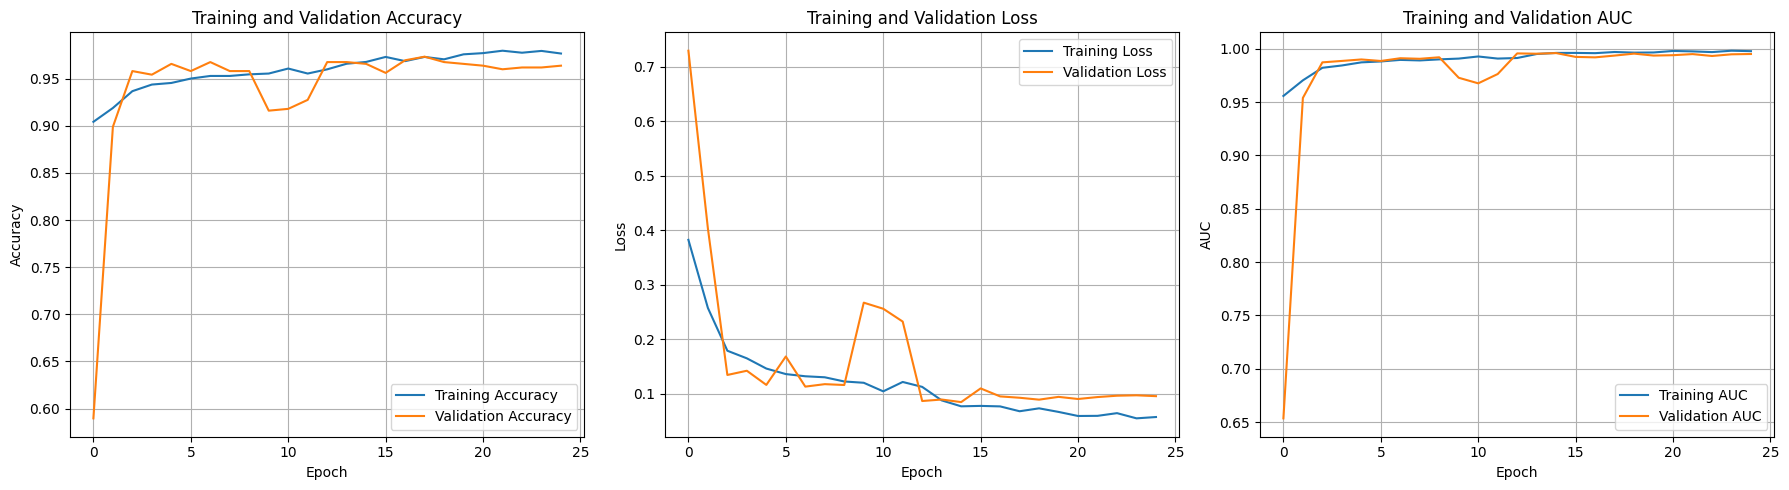

In [6]:
# Train model
history = train_model(
    model, 
    train_images, train_labels,
    val_images, val_labels,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

# Plot training history
plot_training_history(history)

# Save final model
model.save(FINAL_MODEL_PATH)

## Evaluation

2025-03-25 15:04:09.554825: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.86GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 140ms/step - AUC: 0.9409 - accuracy: 0.8709 - loss: 0.4676
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 686ms/step


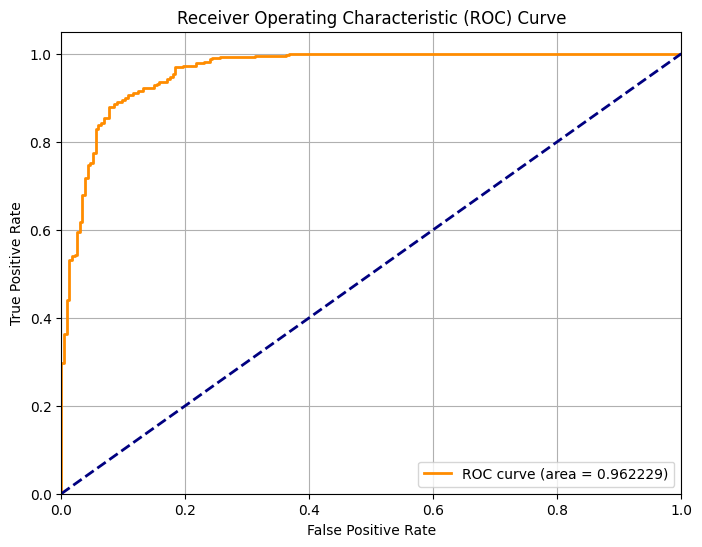

ROC AUC Score: 0.9622


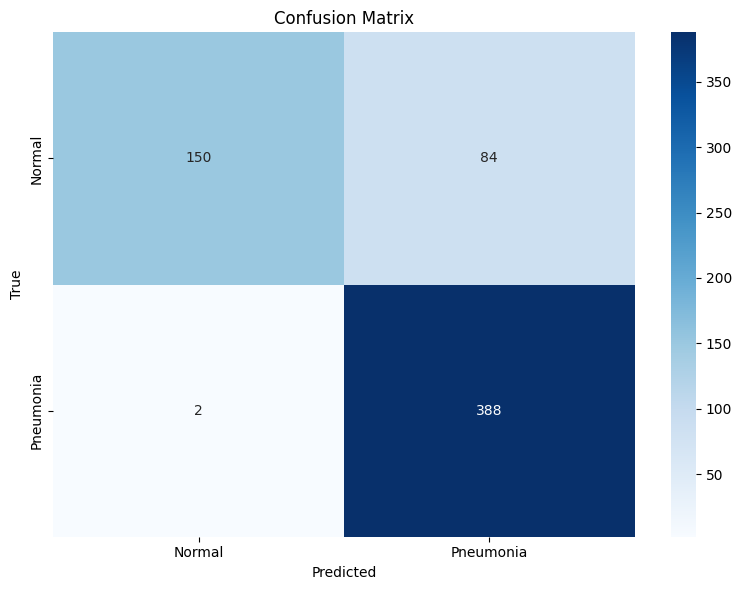

              precision    recall  f1-score   support

      Normal       0.99      0.64      0.78       234
   Pneumonia       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.85       624



In [7]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

### Comparison

In [8]:
# Load best model from training
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Compare with final model
results_best, results_final = compare_models(best_model, model, test_images, test_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 486ms/step - AUC: 0.9409 - accuracy: 0.8709 - loss: 0.4676
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 654ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - AUC: 0.9409 - accuracy: 0.8709 - loss: 0.4676
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step
Best Model (in Training) vs Selected Model (through callbacks):
Test accuracy: 0.862179 vs 0.862179
Test AUC: 0.962229 vs 0.962229
